In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import savgol_filter

In [28]:
mat = loadmat('./data/EEGrestingState.mat')

for k, v in mat.items():
    if not k.startswith('__'):
        print(k, getattr(v, 'shape', None), getattr(v, 'dtype', None))


eegdata (1, 122880) float32
srate (1, 1) uint16


fs 1024, N 122880


(-0.1, 70.0)

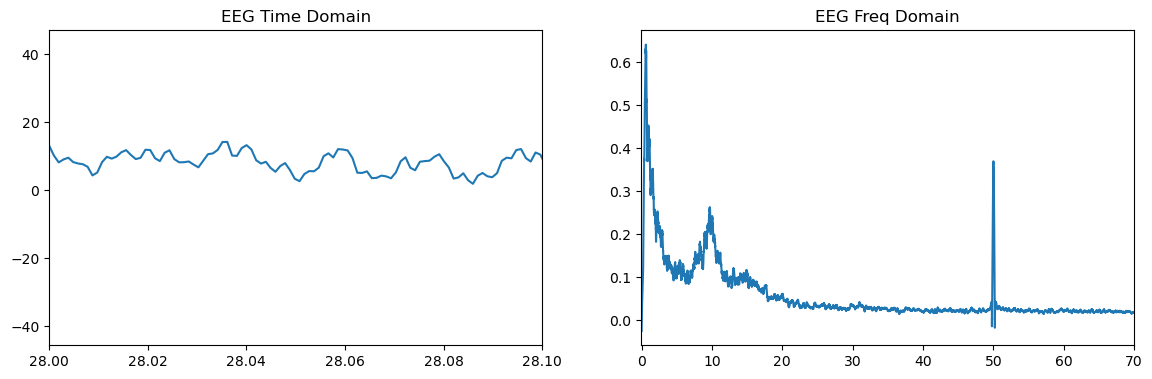

In [90]:
eegdata = mat['eegdata'][0]
fs = mat['srate'].item()

N = eegdata.shape[0]
t = np.arange(0, N) / fs

print(f'fs {fs}, N {N}')

F = np.fft.rfft(eegdata, n=N)
F *= 2/N
F[0] /= 2
hz = np.fft.rfftfreq(N, 1/fs)

plt.figure(figsize=(14, 9))

plt.subplot(221)
plt.plot(t, eegdata)
plt.title("EEG Time Domain")
plt.xlim([28, 28.1])

plt.subplot(222)
plt.plot(hz, savgol_filter(np.abs(F), window_length=51, polyorder=3))
plt.title("EEG Freq Domain")
plt.xlim(-0.1, 70)